# MATH GR5360 Final Project - Notebook 1
## Data Loading & Statistical Tests (Variance Ratio & Push-Response)



In [5]:
PRIMARY_MARKET = 1  

In [6]:
# ============================================================================
# MARKET PARAMETERS DATABASE (from TF_Data.xls)
# ============================================================================

# All 18 primary markets with their parameters
MARKET_DATABASE = {
    # Ticker: (Name, Exchange, PV, Slippage, TickValue, PV_Multiplier)
    'BO': ('Soybean Oil', 'CBOT-CME', 600, 39, 6, 1),
    'DX': ('Dollar Index', 'NYBOT-ICE', 1000, 16.5, 5, 1),
    'HG': ('Copper', 'COMEX-NYMEX-CME', 250, 59.25, 12.5, 1),
    'HO': ('Heating Oil', 'NYMEX-CME', 420, 70.2, 4.2, 100),
    'JO': ('Orange Juice', 'NYBOT-ICE', 150, 183, 7.5, 1),
    'JY': ('Japanese Yen', 'CME', 1250, 53, 6.25, 100),
    'SY': ('Soybeans', 'CBOT-CME', 50, 35.5, 12.5, 1),
    'SB': ('Sugar #11', 'NYBOT-ICE', 1120, 56.76, 11.2, 1),
    'SF': ('Swiss Franc', 'CME', 1250, 25.5, 12.5, 100),
    'TU': ('2-Year Treasury', 'CBOT-CME', 2000, 18.625, 15.625, 1),
    'TY': ('10-Year Treasury', 'CBOT-CME', 1000, 18.625, 15.625, 1),
    'WC': ('Wheat', 'CBOT-CME', 50, 30.5, 12.5, 1),
    'SM': ('Soybean Meal', 'CBOT-CME', 100, 57, 10, 1),
    'CC': ('Cocoa', 'NYBOT-ICE', 10, 103, 10, 1),
    'BZ': ('Schatz', 'EUREX', 1000, 10.5, 5, 1),
    'CL': ('Crude Oil WTI', 'NYMEX-CME', 1000, 46, 10, 1),
    'GC': ('Gold 100oz', 'COMEX-NYMEX-CME', 100, 65, 10, 1),
    'SV': ('Silver', 'COMEX-NYMEX-CME', 5000, 243, 25, 0.01),
}

# Group to ticker mapping (verify with your instructor!)
GROUP_TO_TICKER = {
    1: 'BO', 2: 'DX', 3: 'HG', 4: 'HO', 5: 'JO', 6: 'JY',
    7: 'SY', 8: 'SB', 9: 'SF', 10: 'TU', 11: 'TY', 12: 'WC',
    13: 'SM', 14: 'CC', 15: 'BZ', 16: 'CL', 17: 'GC', 18: 'SV'
}

In [7]:
# ============================================================================
# AUTO-CONFIGURE MARKET BASED ON GROUP NUMBER
# ============================================================================

TICKER = GROUP_TO_TICKER[PRIMARY_MARKET]
market_info = MARKET_DATABASE[TICKER]

MARKET = {
    'ticker': TICKER,
    'name': market_info[0],
    'exchange': market_info[1],
    'PV': market_info[2],           # Point Value
    'slpg': market_info[3],         # Slippage (round-turn, USD)
    'tick_value': market_info[4],
    'pv_multiplier': market_info[5],
    'E0': 100000,                   # Initial equity
}

# Data file path
DATA_FILE = f'../data/{TICKER}-5minHLV.csv'

print("=" * 70)
print(f"GROUP {PRIMARY_MARKET} - PRIMARY MARKET CONFIGURATION")
print("=" * 70)
print(f"Ticker:       {MARKET['ticker']}")
print(f"Name:         {MARKET['name']}")
print(f"Exchange:     {MARKET['exchange']}")
print(f"Point Value:  ${MARKET['PV']:,}")
print(f"Slippage:     ${MARKET['slpg']} per round-turn")
print(f"Tick Value:   ${MARKET['tick_value']}")
print(f"Initial Equity: ${MARKET['E0']:,}")
print(f"\nData file:   {DATA_FILE}")
print("=" * 70)

GROUP 1 - PRIMARY MARKET CONFIGURATION
Ticker:       BO
Name:         Soybean Oil
Exchange:     CBOT-CME
Point Value:  $600
Slippage:     $39 per round-turn
Tick Value:   $6
Initial Equity: $100,000

Data file:   ../data/BO-5minHLV.csv


In [8]:
# ============================================================================
# IMPORTS
# ============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from numba import jit
from tqdm.notebook import tqdm
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Plot settings
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12

print(f"Notebook started: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

Notebook started: 2026-04-15 20:50:34


---
## 2. Data Loading

In [9]:
def load_ohlc_data(filepath):
    """
    Load 5-minute OHLC data from CSV file.
    Compatible with ezread.m format.
    """
    df = pd.read_csv(filepath)
    df.columns = df.columns.str.strip().str.lower()
    print(f"Columns found: {list(df.columns)}")
    
    # Parse datetime
    if 'date' in df.columns and 'time' in df.columns:
        df['datetime'] = pd.to_datetime(
            df['date'].astype(str) + ' ' + df['time'].astype(str),
            format='mixed'
        )
    elif 'datetime' in df.columns:
        df['datetime'] = pd.to_datetime(df['datetime'])
    else:
        df['datetime'] = pd.to_datetime(df.iloc[:, 0])
    
    df.set_index('datetime', inplace=True)
    df.sort_index(inplace=True)
    
    # Standardize column names
    rename_map = {}
    for col in df.columns:
        cl = col.lower()
        if 'open' in cl: rename_map[col] = 'Open'
        elif 'high' in cl: rename_map[col] = 'High'
        elif 'low' in cl: rename_map[col] = 'Low'
        elif 'close' in cl: rename_map[col] = 'Close'
        elif 'vol' in cl: rename_map[col] = 'Volume'
    
    df.rename(columns=rename_map, inplace=True)
    cols = [c for c in ['Open', 'High', 'Low', 'Close', 'Volume'] if c in df.columns]
    return df[cols].astype(float)


def validate_data(df):
    """Validate OHLC data integrity."""
    print("\n" + "=" * 60)
    print("DATA VALIDATION")
    print("=" * 60)
    print(f"Total bars: {len(df):,}")
    print(f"Date range: {df.index.min()} to {df.index.max()}")
    print(f"Duration: {(df.index.max() - df.index.min()).days / 365.25:.1f} years")
    
    # Check integrity
    issues = []
    if (df['High'] < df['Low']).any():
        issues.append(f"High < Low: {(df['High'] < df['Low']).sum()} bars")
    if (df['High'] < df['Open']).any() or (df['High'] < df['Close']).any():
        issues.append("High < Open or Close")
    
    if issues:
        print(f"\n⚠️ Issues: {issues}")
    else:
        print("\n✓ Data integrity OK")
    
    print(f"\nPrice range: {df['Close'].min():.4f} to {df['Close'].max():.4f}")
    return len(issues) == 0

In [10]:
# ============================================================================
# LOAD DATA
# ============================================================================

try:
    df = load_ohlc_data(DATA_FILE)
    validate_data(df)
    
except FileNotFoundError:
    print(f"⚠️ Data file not found: {DATA_FILE}")
    print(f"\nPlease download {TICKER}-5min.csv from CourseWorks")
    print("and place it in the ../data/ folder.")
    print("\n🔧 Generating SYNTHETIC data for testing...\n")
    
    # Generate synthetic data
    np.random.seed(42 + PRIMARY_MARKET)  # Different seed per group
    n = 250000
    dates = pd.date_range('2008-01-01', periods=n, freq='5min')
    
    # Simulate price (starting value depends on market)
    start_prices = {'BO': 30, 'DX': 90, 'HG': 3, 'HO': 2, 'JO': 100, 'JY': 0.009,
                    'SY': 900, 'SB': 15, 'SF': 1, 'TU': 105, 'TY': 115, 'WC': 500,
                    'SM': 300, 'CC': 2500, 'BZ': 110, 'CL': 60, 'GC': 1300, 'SV': 15}
    
    start_price = start_prices.get(TICKER, 100)
    returns = np.random.randn(n) * 0.0003
    trend = np.sin(np.linspace(0, 8*np.pi, n)) * 0.0001
    close = start_price * np.exp(np.cumsum(returns + trend))
    
    df = pd.DataFrame({
        'Open': close * (1 + np.random.randn(n) * 0.0001),
        'High': close * (1 + np.abs(np.random.randn(n) * 0.0003)),
        'Low': close * (1 - np.abs(np.random.randn(n) * 0.0003)),
        'Close': close
    }, index=dates)
    df['High'] = df[['Open', 'High', 'Close']].max(axis=1)
    df['Low'] = df[['Open', 'Low', 'Close']].min(axis=1)
    
    print(f"✓ Generated {len(df):,} bars of synthetic data")
    validate_data(df)

⚠️ Data file not found: ../data/BO-5minHLV.csv

Please download BO-5min.csv from CourseWorks
and place it in the ../data/ folder.

🔧 Generating SYNTHETIC data for testing...

✓ Generated 250,000 bars of synthetic data

DATA VALIDATION
Total bars: 250,000
Date range: 2008-01-01 00:00:00 to 2010-05-18 01:15:00
Duration: 2.4 years

✓ Data integrity OK

Price range: 25.6615 to 239.1140


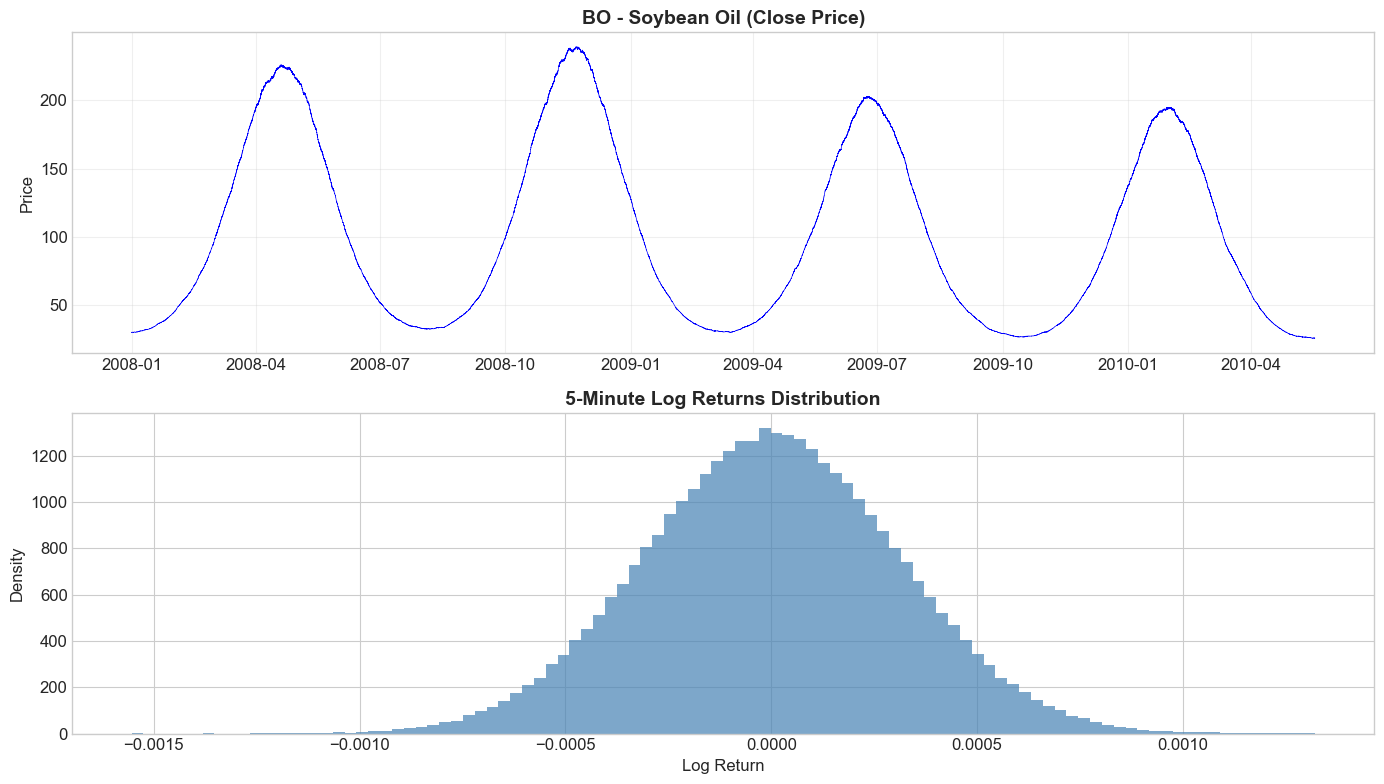


Returns: mean=-6.12e-07, std=0.0003
Skewness: -0.002, Kurtosis: -0.006


In [11]:
# Visualize data
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

ax1 = axes[0]
ax1.plot(df.index, df['Close'], 'b-', linewidth=0.5)
ax1.set_title(f"{MARKET['ticker']} - {MARKET['name']} (Close Price)", fontsize=14, fontweight='bold')
ax1.set_ylabel('Price')
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
returns = np.log(df['Close'] / df['Close'].shift(1)).dropna()
ax2.hist(returns, bins=100, density=True, alpha=0.7, color='steelblue')
ax2.set_title('5-Minute Log Returns Distribution', fontsize=14, fontweight='bold')
ax2.set_xlabel('Log Return')
ax2.set_ylabel('Density')

plt.tight_layout()
plt.savefig(f'../results/01_{TICKER}_data_overview.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nReturns: mean={returns.mean():.2e}, std={returns.std():.4f}")
print(f"Skewness: {stats.skew(returns):.3f}, Kurtosis: {stats.kurtosis(returns):.3f}")

---
## 3. Variance Ratio Test

Tests whether variance scales linearly with time (random walk hypothesis).

- **VR > 1**: Trend-following (positive autocorrelation)
- **VR < 1**: Mean-reverting (negative autocorrelation)

In [12]:
def variance_ratio_test(returns, k, robust=True):
    """Lo-MacKinlay Variance Ratio test."""
    returns = np.asarray(returns)
    T = len(returns)
    
    if T < k + 10:
        return {'VR': np.nan, 'z_stat': np.nan, 'p_value': np.nan}
    
    mu = returns.mean()
    sigma2_1 = np.sum((returns - mu) ** 2) / (T - 1)
    
    ret_k = np.array([returns[i:i+k].sum() for i in range(T - k + 1)])
    m = k * (T - k + 1) * (1 - k / T)
    sigma2_k = np.sum((ret_k - k * mu) ** 2) / m
    
    VR = sigma2_k / sigma2_1
    
    if robust:
        delta = 0
        for j in range(1, k):
            weight = 2 * (k - j) / k
            sum_sq = np.sum((returns - mu) ** 2)
            if sum_sq == 0:
                continue
            numer = np.sum((returns[j:] - mu) ** 2 * (returns[:-j] - mu) ** 2)
            delta_j = T * numer / (sum_sq ** 2)
            delta += weight ** 2 * delta_j
        z = (VR - 1) / np.sqrt(delta) if delta > 0 else 0
    else:
        theta = 2 * (2 * k - 1) * (k - 1) / (3 * k * T)
        z = (VR - 1) / np.sqrt(theta)
    
    p_value = 2 * (1 - stats.norm.cdf(abs(z)))
    return {'VR': VR, 'z_stat': z, 'p_value': p_value}

In [13]:
# Run Variance Ratio tests
returns = np.log(df['Close'] / df['Close'].shift(1)).dropna().values

# k values (in 5-min bars)
k_values = [2, 4, 8, 12, 24, 48, 78, 156, 312, 780, 1560, 3120]

def bars_to_time(k):
    mins = k * 5
    if mins < 60: return f"{mins}min"
    elif mins < 390: return f"{mins/60:.1f}hr"
    else: return f"{mins/390:.1f}d"

print("Running Variance Ratio Tests...")
vr_results = []

for k in tqdm(k_values):
    result = variance_ratio_test(returns, k)
    vr_results.append({
        'k': k,
        'time_scale': bars_to_time(k),
        'VR': result['VR'],
        'z_stat': result['z_stat'],
        'p_value': result['p_value'],
        'significant': result['p_value'] < 0.05,
        'pattern': 'trend' if result['VR'] > 1 else 'mean_revert'
    })

vr_df = pd.DataFrame(vr_results)
print("\n" + vr_df.to_string(index=False))

Running Variance Ratio Tests...


  0%|          | 0/12 [00:00<?, ?it/s]


   k time_scale         VR   z_stat  p_value  significant pattern
   2      10min   1.047553 0.047636 0.962006        False   trend
   4      20min   1.152011 0.081367 0.935150        False   trend
   8      40min   1.358267 0.121117 0.903598        False   trend
  12      1.0hr   1.563887 0.150368 0.880474        False   trend
  24      2.0hr   2.182325 0.215760 0.829175        False   trend
  48      4.0hr   3.431059 0.308689 0.757558        False   trend
  78       1.0d   4.994921 0.395455 0.692507        False   trend
 156       2.0d   9.081578 0.562852 0.573535        False   trend
 312       4.0d  17.271552 0.799329 0.424100        False   trend
 780      10.0d  41.932302 1.269992 0.204088        False   trend
1560      20.0d  83.271225 1.804666 0.071127        False   trend
3120      40.0d 166.562007 2.569125 0.010196         True   trend


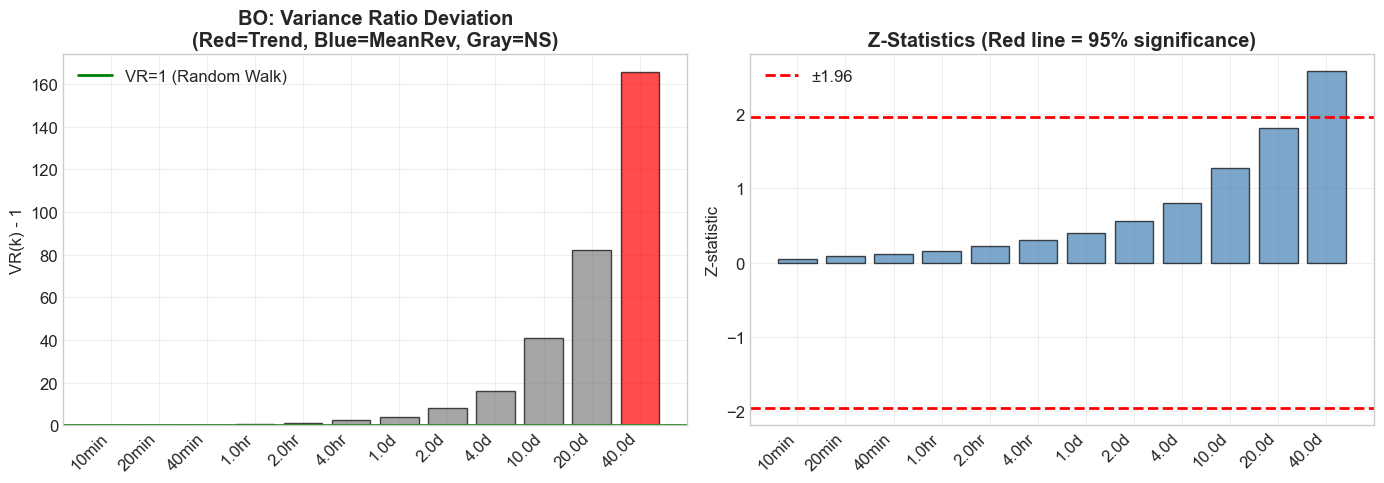

In [14]:
# Visualize VR results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
colors = ['red' if s and v > 1 else 'blue' if s else 'gray' 
          for s, v in zip(vr_df['significant'], vr_df['VR'])]
ax1.bar(range(len(vr_df)), vr_df['VR'] - 1, color=colors, alpha=0.7, edgecolor='black')
ax1.axhline(y=0, color='green', linewidth=2, label='VR=1 (Random Walk)')
ax1.set_xticks(range(len(vr_df)))
ax1.set_xticklabels(vr_df['time_scale'], rotation=45, ha='right')
ax1.set_ylabel('VR(k) - 1')
ax1.set_title(f'{TICKER}: Variance Ratio Deviation\n(Red=Trend, Blue=MeanRev, Gray=NS)', fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
ax2.bar(range(len(vr_df)), vr_df['z_stat'], color='steelblue', alpha=0.7, edgecolor='black')
ax2.axhline(y=1.96, color='red', linestyle='--', linewidth=2, label='±1.96')
ax2.axhline(y=-1.96, color='red', linestyle='--', linewidth=2)
ax2.set_xticks(range(len(vr_df)))
ax2.set_xticklabels(vr_df['time_scale'], rotation=45, ha='right')
ax2.set_ylabel('Z-statistic')
ax2.set_title('Z-Statistics (Red line = 95% significance)', fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'../results/02_{TICKER}_variance_ratio.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. Push-Response Test

Tests how prices respond to directional "pushes".

In [15]:
@jit(nopython=True, cache=True)
def calc_push_response(prices, pw, rw):
    n = len(prices)
    total = pw + rw
    if n < total + 1:
        return np.array([0.0]), np.array([0.0])
    
    n_obs = n - total
    push_ret = np.zeros(n_obs)
    resp_ret = np.zeros(n_obs)
    
    for i in range(n_obs):
        if prices[i] > 0 and prices[i + pw] > 0:
            push_ret[i] = (prices[i + pw] - prices[i]) / prices[i]
            resp_ret[i] = (prices[i + total] - prices[i + pw]) / prices[i + pw]
    
    return push_ret, resp_ret


def push_response_test(prices, pw, rw):
    prices = np.asarray(prices, dtype=np.float64)
    push_ret, resp_ret = calc_push_response(prices, pw, rw)
    
    if len(push_ret) < 50:
        return {'error': True}
    
    slope, intercept, r_value, p_value, std_err = stats.linregress(push_ret, resp_ret)
    
    return {
        'pw': pw, 'rw': rw,
        'beta': slope,
        'p_value': p_value,
        'correlation': np.corrcoef(push_ret, resp_ret)[0, 1],
        'significant': p_value < 0.05,
        'pattern': 'trend' if slope > 0 else 'mean_revert',
        'error': False
    }

In [16]:
# Run Push-Response tests
prices = df['Close'].values
windows = [6, 12, 24, 48, 78, 156, 312, 780]

print("Running Push-Response Tests...")
pr_results = []

for pw in tqdm(windows, desc="Push windows"):
    for rw in windows:
        result = push_response_test(prices, pw, rw)
        if not result.get('error', True):
            pr_results.append(result)

pr_df = pd.DataFrame(pr_results)
print(f"\nCompleted {len(pr_df)} tests")

Running Push-Response Tests...


Push windows:   0%|          | 0/8 [00:00<?, ?it/s]


Completed 64 tests


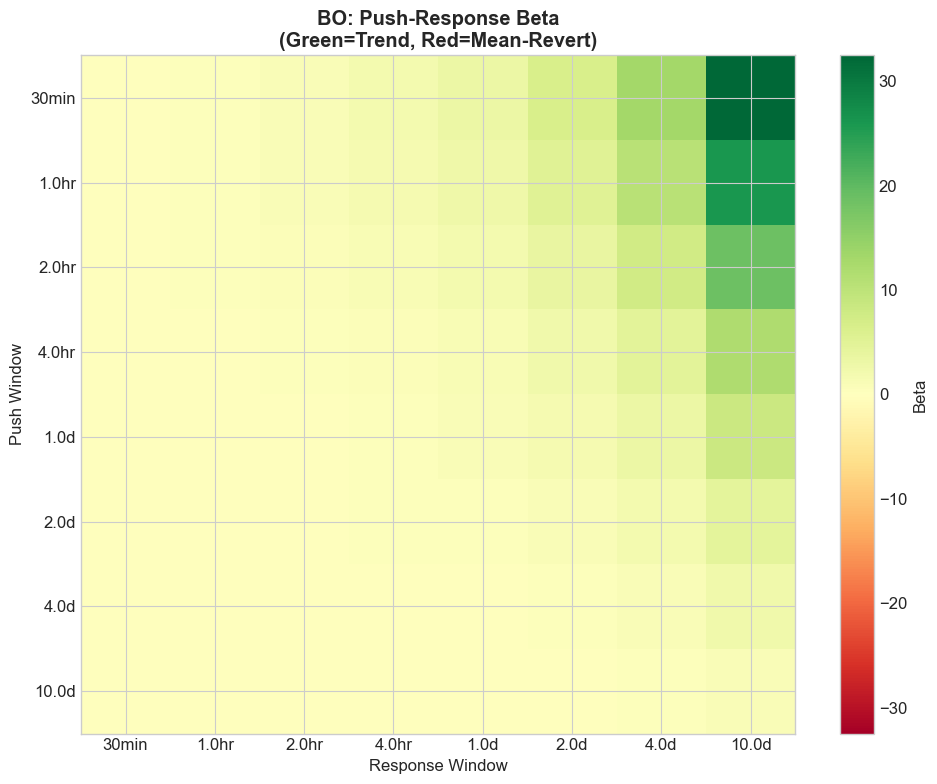

In [17]:
# Visualize Push-Response
pivot = pr_df.pivot(index='pw', columns='rw', values='beta')

plt.figure(figsize=(10, 8))
vmax = max(abs(pivot.values.min()), abs(pivot.values.max()))
plt.imshow(pivot.values, cmap='RdYlGn', aspect='auto', vmin=-vmax, vmax=vmax)
plt.colorbar(label='Beta')
plt.xticks(range(len(pivot.columns)), [bars_to_time(c) for c in pivot.columns])
plt.yticks(range(len(pivot.index)), [bars_to_time(i) for i in pivot.index])
plt.xlabel('Response Window')
plt.ylabel('Push Window')
plt.title(f'{TICKER}: Push-Response Beta\n(Green=Trend, Red=Mean-Revert)', fontweight='bold')
plt.tight_layout()
plt.savefig(f'../results/03_{TICKER}_push_response.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Summary & Recommendation

In [18]:
print("\n" + "=" * 70)
print(f"MARKET INEFFICIENCY ANALYSIS: {MARKET['ticker']} ({MARKET['name']})")
print("=" * 70)

# VR Summary
vr_trend = vr_df[(vr_df['significant']) & (vr_df['VR'] > 1)]
vr_mr = vr_df[(vr_df['significant']) & (vr_df['VR'] < 1)]

print("\n1. VARIANCE RATIO:")
if len(vr_trend) > 0:
    print(f"   ✓ Trend-following at: {', '.join(vr_trend['time_scale'].tolist())}")
if len(vr_mr) > 0:
    print(f"   ✓ Mean-reversion at: {', '.join(vr_mr['time_scale'].tolist())}")
if len(vr_trend) == 0 and len(vr_mr) == 0:
    print("   No significant patterns detected")

# PR Summary
sig_pr = pr_df[pr_df['significant']]
pr_trend = len(sig_pr[sig_pr['pattern'] == 'trend'])
pr_mr = len(sig_pr[sig_pr['pattern'] == 'mean_revert'])

print("\n2. PUSH-RESPONSE:")
print(f"   Trend-following signals: {pr_trend}")
print(f"   Mean-reverting signals: {pr_mr}")

# Recommendation
trend_score = len(vr_trend) + pr_trend
mr_score = len(vr_mr) + pr_mr

print("\n3. RECOMMENDATION:")
if trend_score > mr_score:
    print("   ✅ TREND-FOLLOWING strategy (Channel WithDDControl) is appropriate")
elif mr_score > trend_score:
    print("   ⚠️ Market shows mean-reversion; trend strategy may underperform")
else:
    print("   ⚖️ Mixed evidence; proceed with Channel WithDDControl")

print("\n" + "=" * 70)


MARKET INEFFICIENCY ANALYSIS: BO (Soybean Oil)

1. VARIANCE RATIO:
   ✓ Trend-following at: 40.0d

2. PUSH-RESPONSE:
   Trend-following signals: 64
   Mean-reverting signals: 0

3. RECOMMENDATION:
   ✅ TREND-FOLLOWING strategy (Channel WithDDControl) is appropriate



---
## Next: Notebook 02 - Strategy & Walk-Forward

**End of Notebook 01**